In [ ]:
# [Pipeline 3.0] Setup — replicate preprocessing pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load data
url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = pd.read_csv(url)

# Replicate preprocessing steps
df_prep = df.copy()
df_prep.replace('?', np.nan, inplace=True)
df_prep.drop(columns=['education', 'fnlwgt'], inplace=True, errors='ignore')

X = df_prep.drop(columns=['income'])
y = df_prep['income']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Best preprocessing config from 02_preprocessing.ipynb
best_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

X_train_processed = best_preprocessor.fit_transform(X_train)
X_test_processed = best_preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (39073, 91)
X_test_processed shape : (9769, 91)


## [Pipeline 3.1] Feature Extraction

Sau bước preprocessing, dữ liệu đã được chuẩn hóa và mã hóa one-hot, tạo ra 91 features.

Trong bước này, nhóm xây dựng hai nhánh đặc trưng để so sánh:

- **Full features**: giữ nguyên toàn bộ 91 features sau preprocessing.
- **PCA 95%**: áp dụng PCA trên tập train và giữ lại số chiều đủ giải thích 95% phương sai.

Lưu ý: PCA chỉ được fit trên tập train, sau đó transform tập test để tránh data leakage.

In [ ]:
# [Pipeline 3.1] Feature Extraction - Full features vs PCA 95%

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.decomposition import PCA

# Convert sparse matrix to dense if needed
# PCA in sklearn works best with dense input.
def to_dense_array(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)

X_train_full = to_dense_array(X_train_processed).astype(np.float32)
X_test_full = to_dense_array(X_test_processed).astype(np.float32)

print("Full feature branch")
print("X_train_full shape:", X_train_full.shape)
print("X_test_full shape :", X_test_full.shape)

# Safety check
assert X_train_full.shape[0] == len(y_train), "Mismatch between X_train and y_train"
assert X_test_full.shape[0] == len(y_test), "Mismatch between X_test and y_test"

Full feature branch
X_train_full shape: (39073, 91)
X_test_full shape : (9769, 91)


In [ ]:
# Clean target labels
# Adult income labels are usually '<=50K' and '>50K'

y_train_clean = pd.Series(y_train).astype(str).str.strip().str.replace(".", "", regex=False)
y_test_clean = pd.Series(y_test).astype(str).str.strip().str.replace(".", "", regex=False)

print("Train label distribution:")
print(y_train_clean.value_counts())
print("\nTest label distribution:")
print(y_test_clean.value_counts())

label_map = {
    "<=50K": 0,
    ">50K": 1
}

# Encode labels if they match expected Adult labels
if set(y_train_clean.unique()).issubset(set(label_map.keys())):
    y_train_model = y_train_clean.map(label_map).astype(int).to_numpy()
    y_test_model = y_test_clean.map(label_map).astype(int).to_numpy()
    print("\nLabels encoded successfully:")
    print(label_map)
else:
    y_train_model = y_train_clean.to_numpy()
    y_test_model = y_test_clean.to_numpy()
    print("\nLabels kept as original strings because unexpected labels were found.")

print("y_train_model shape:", y_train_model.shape)
print("y_test_model shape :", y_test_model.shape)

Train label distribution:
income
<=50K    29724
>50K      9349
Name: count, dtype: int64

Test label distribution:
income
<=50K    7431
>50K     2338
Name: count, dtype: int64

Labels encoded successfully:
{'<=50K': 0, '>50K': 1}
y_train_model shape: (39073,)
y_test_model shape : (9769,)


In [ ]:
# PCA branch: keep 95% explained variance
# Important: fit PCA on training set only, then transform test set.

pca_95 = PCA(n_components=0.95, svd_solver="full", random_state=42)

X_train_pca = pca_95.fit_transform(X_train_full)
X_test_pca = pca_95.transform(X_test_full)

print("PCA 95% feature branch")
print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape :", X_test_pca.shape)
print(f"Number of PCA components: {pca_95.n_components_}")
print(f"Explained variance retained: {pca_95.explained_variance_ratio_.sum():.4f}")

PCA 95% feature branch
X_train_pca shape: (39073, 25)
X_test_pca shape : (9769, 25)
Number of PCA components: 25
Explained variance retained: 0.9512


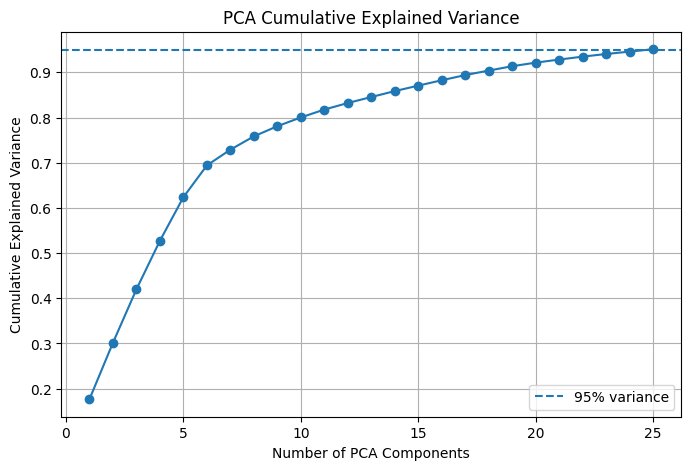

In [ ]:
# Visualize cumulative explained variance of selected PCA components

cumulative_variance = np.cumsum(pca_95.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(y=0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Store feature branches for model training later

feature_sets = {
    "full_features": {
        "X_train": X_train_full,
        "X_test": X_test_full
    },
    "pca_95": {
        "X_train": X_train_pca,
        "X_test": X_test_pca
    }
}

for name, data in feature_sets.items():
    print(f"{name}:")
    print("  X_train:", data["X_train"].shape)
    print("  X_test :", data["X_test"].shape)

full_features:
  X_train: (39073, 91)
  X_test : (9769, 91)
pca_95:
  X_train: (39073, 25)
  X_test : (9769, 25)


In [ ]:
# Save extracted features for reproducibility

os.makedirs("features", exist_ok=True)

np.save("features/X_train_full.npy", X_train_full)
np.save("features/X_test_full.npy", X_test_full)

np.save("features/X_train_pca95.npy", X_train_pca)
np.save("features/X_test_pca95.npy", X_test_pca)

np.save("features/y_train.npy", y_train_model)
np.save("features/y_test.npy", y_test_model)

print("Feature files saved to features/ folder:")
print(os.listdir("features"))

Feature files saved to features/ folder:
['X_train_pca95.npy', 'y_train.npy', 'X_train_full.npy', 'X_test_pca95.npy', 'X_test_full.npy', 'y_test.npy']


## [Pipeline 3.2] Baseline Model Training

Sau khi hoàn thành bước trích xuất đặc trưng, nhóm tiến hành huấn luyện các mô hình baseline trên cả hai nhánh đặc trưng:

- `full_features`: giữ nguyên toàn bộ 91 đặc trưng sau preprocessing.
- `pca_95`: giảm chiều bằng PCA và giữ lại 95% phương sai.

Bốn mô hình học máy truyền thống được sử dụng gồm:

1. **Logistic Regression**  
   Đây là mô hình tuyến tính phù hợp cho bài toán phân loại nhị phân, có thời gian huấn luyện nhanh và thường được dùng làm baseline mạnh cho dữ liệu dạng bảng.

2. **Linear SVM**  
   SVM được đưa vào để đáp ứng yêu cầu so sánh các mô hình truyền thống. Trong thí nghiệm ban đầu, nhóm đã thử SVM với kernel RBF, nhưng mô hình này có thời gian huấn luyện dài hơn đáng kể. Vì notebook cuối cùng cần chạy ổn định bằng `Runtime → Run all`, nhóm sử dụng **Linear SVM** làm đại diện chính cho nhóm SVM. Linear SVM vẫn là một mô hình SVM hợp lệ, nhưng hiệu quả tính toán tốt hơn trên tập Adult có số lượng mẫu tương đối lớn.

3. **Random Forest**  
   Đây là mô hình ensemble dựa trên nhiều cây quyết định. Random Forest có khả năng mô hình hóa quan hệ phi tuyến và tương tác giữa các đặc trưng, phù hợp với dữ liệu tabular.

4. **Gaussian Naive Bayes**  
   Mô hình này được dùng để so sánh với các mô hình còn lại và liên hệ với phần lý thuyết Naive Bayes. Tuy nhiên, do GaussianNB giả định các đặc trưng liên tục có phân phối Gaussian, mô hình này có thể không phù hợp hoàn toàn với dữ liệu sau one-hot encoding.

Tham số `class_weight='balanced'` được sử dụng cho Logistic Regression, Linear SVM và Random Forest vì tập Adult có sự mất cân bằng giữa hai lớp thu nhập. Việc cân bằng trọng số lớp giúp mô hình quan tâm nhiều hơn đến lớp thiểu số `>50K`, thay vì tối ưu chủ yếu cho lớp đa số `<=50K`.

F1-score được sử dụng làm chỉ số chính để so sánh mô hình, vì chỉ số này cân bằng giữa precision và recall, phù hợp hơn accuracy trong bối cảnh dữ liệu có mất cân bằng lớp.

In [ ]:
# [Pipeline 3.2] Import libraries for model training and evaluation

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [ ]:
# Define baseline classical models
# SVM RBF is replaced by Linear SVM to keep the notebook efficient for Run all.

baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42,
        max_iter=10000,
        dual=False
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gaussian Naive Bayes": GaussianNB()
}

print("Baseline models:")
for model_name in baseline_models.keys():
    print("-", model_name)

Baseline models:
- Logistic Regression
- Linear SVM
- Random Forest
- Gaussian Naive Bayes


In [ ]:
# Helper function to train and evaluate one model

def train_and_evaluate_model(model, model_name, feature_set_name, X_train, X_test, y_train, y_test):
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    # Get score for ROC-AUC
    # Some models have predict_proba, SVM has decision_function.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan

    result = {
        "feature_set": feature_set_name,
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "train_time_sec": train_time
    }

    return model, y_pred, result

In [ ]:
# Train baseline models on both feature branches

trained_models = {}
baseline_results = []
baseline_predictions = {}

for feature_set_name, data in feature_sets.items():
    print("=" * 80)
    print(f"Feature set: {feature_set_name}")
    print("=" * 80)

    X_train_current = data["X_train"]
    X_test_current = data["X_test"]

    for model_name, model in baseline_models.items():
        print(f"\nTraining: {model_name}")

        trained_model, y_pred, result = train_and_evaluate_model(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            X_train=X_train_current,
            X_test=X_test_current,
            y_train=y_train_model,
            y_test=y_test_model
        )

        key = f"{feature_set_name}__{model_name}"
        trained_models[key] = trained_model
        baseline_predictions[key] = y_pred
        baseline_results.append(result)

        print(f"Done: {model_name}")
        print(f"F1-score: {result['f1_score']:.4f}")
        print(f"Accuracy: {result['accuracy']:.4f}")
        print(f"ROC-AUC : {result['roc_auc']:.4f}")
        print(f"Training time: {result['train_time_sec']:.2f} seconds")

Feature set: full_features

Training: Logistic Regression
Done: Logistic Regression
F1-score: 0.6760
Accuracy: 0.8073
ROC-AUC : 0.9051
Training time: 2.02 seconds

Training: Linear SVM
Done: Linear SVM
F1-score: 0.6732
Accuracy: 0.8018
ROC-AUC : 0.9045
Training time: 0.84 seconds

Training: Random Forest
Done: Random Forest
F1-score: 0.6687
Accuracy: 0.8481
ROC-AUC : 0.8940
Training time: 11.84 seconds

Training: Gaussian Naive Bayes
Done: Gaussian Naive Bayes
F1-score: 0.5291
Accuracy: 0.6014
ROC-AUC : 0.8453
Training time: 0.06 seconds
Feature set: pca_95

Training: Logistic Regression
Done: Logistic Regression
F1-score: 0.6752
Accuracy: 0.8057
ROC-AUC : 0.9031
Training time: 0.55 seconds

Training: Linear SVM
Done: Linear SVM
F1-score: 0.6697
Accuracy: 0.7979
ROC-AUC : 0.9025
Training time: 0.69 seconds

Training: Random Forest
Done: Random Forest
F1-score: 0.6403
Accuracy: 0.8383
ROC-AUC : 0.8877
Training time: 40.09 seconds

Training: Gaussian Naive Bayes
Done: Gaussian Naive Baye

In [ ]:
# Create baseline result table

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df.sort_values(
    by=["f1_score", "roc_auc"],
    ascending=False
).reset_index(drop=True)

baseline_results_df

,feature_set,model,accuracy,precision,recall,f1_score,roc_auc,train_time_sec
0,full_features,Logistic Regression,0.807350,0.565706,0.839607,0.675964,0.905146,2.023212
1,pca_95,Logistic Regression,0.805712,0.562750,0.843884,0.675222,0.903102,0.545011
2,full_features,Linear SVM,0.801822,0.556051,0.852866,0.673194,0.904485,0.835600
3,pca_95,Linear SVM,0.797932,0.550027,0.855860,0.669679,0.902457,0.691150
4,full_features,Random Forest,0.848091,0.699346,0.640719,0.668750,0.894001,11.838197
5,pca_95,Random Forest,0.838264,0.684518,0.601369,0.640255,0.887653,40.086429
6,pca_95,Gaussian Naive Bayes,0.812366,0.609260,0.602224,0.605722,0.840154,0.010641
7,full_features,Gaussian Naive Bayes,0.601392,0.368847,0.935843,0.529141,0.845343,0.061766


In [ ]:
# Save baseline results

os.makedirs("results", exist_ok=True)

baseline_results_df.to_csv("results/baseline_results.csv", index=False)

print("Saved baseline results to results/baseline_results.csv")
print(os.listdir("results"))

Saved baseline results to results/baseline_results.csv
['baseline_results.csv']


In [ ]:
# Best baseline model based on F1-score

best_baseline = baseline_results_df.iloc[0]

print("Best baseline model:")
print("Feature set :", best_baseline["feature_set"])
print("Model       :", best_baseline["model"])
print("Accuracy    :", round(best_baseline["accuracy"], 4))
print("Precision   :", round(best_baseline["precision"], 4))
print("Recall      :", round(best_baseline["recall"], 4))
print("F1-score    :", round(best_baseline["f1_score"], 4))
print("ROC-AUC     :", round(best_baseline["roc_auc"], 4))
print("Train time  :", round(best_baseline["train_time_sec"], 2), "seconds")

Best baseline model:
Feature set : full_features
Model       : Logistic Regression
Accuracy    : 0.8073
Precision   : 0.5657
Recall      : 0.8396
F1-score    : 0.676
ROC-AUC     : 0.9051
Train time  : 2.02 seconds


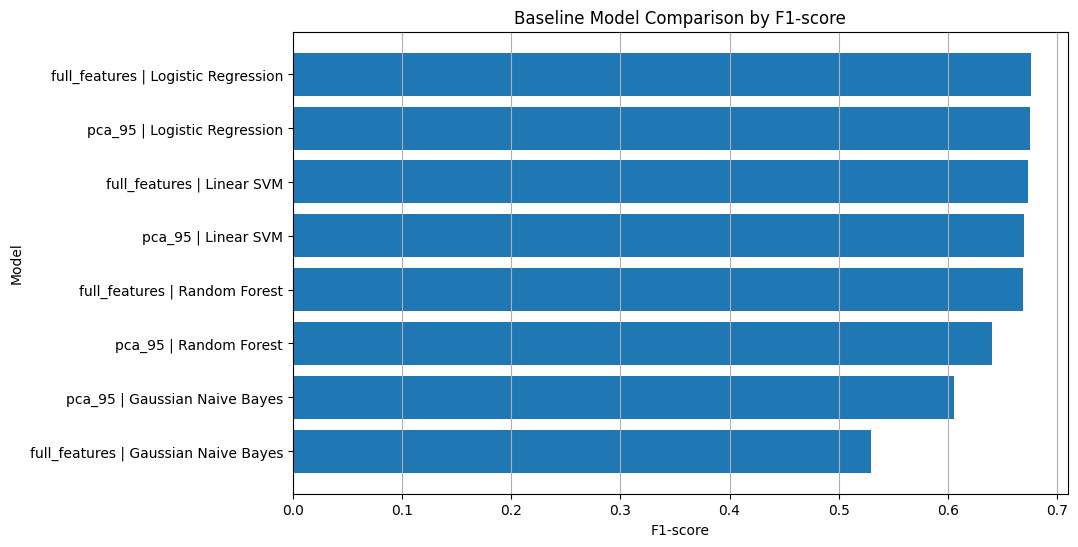

In [ ]:
# Visualize baseline F1-score comparison

plt.figure(figsize=(10, 6))

labels = baseline_results_df["feature_set"] + " | " + baseline_results_df["model"]

plt.barh(labels, baseline_results_df["f1_score"])
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.title("Baseline Model Comparison by F1-score")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

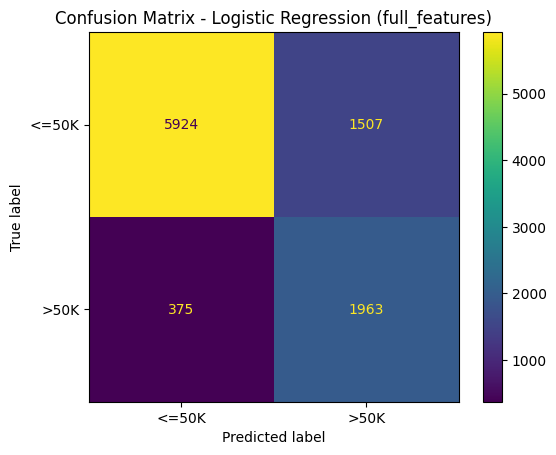

In [ ]:
# Confusion matrix for best baseline model

best_key = f"{best_baseline['feature_set']}__{best_baseline['model']}"
best_y_pred = baseline_predictions[best_key]

cm = confusion_matrix(y_test_model, best_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_baseline['model']} ({best_baseline['feature_set']})")
plt.show()

### Nhận xét Confusion Matrix

Với mô hình baseline tốt nhất là Logistic Regression trên `full_features`, ma trận nhầm lẫn cho thấy mô hình dự đoán đúng 5924 mẫu thuộc lớp `<=50K` và 1963 mẫu thuộc lớp `>50K`.

Đối với lớp `>50K`, mô hình có recall cao, đạt 0.84, nghĩa là mô hình phát hiện được phần lớn các mẫu có thu nhập cao. Tuy nhiên, precision của lớp này chỉ đạt 0.57, cho thấy vẫn còn khá nhiều mẫu `<=50K` bị dự đoán nhầm thành `>50K`.

Điều này phản ánh đặc điểm mất cân bằng của tập dữ liệu Adult: lớp `<=50K` chiếm số lượng lớn hơn đáng kể so với lớp `>50K`. Vì vậy, F1-score được sử dụng làm chỉ số chính để cân bằng giữa precision và recall, thay vì chỉ dựa vào accuracy.

In [ ]:
# Detailed classification report for best baseline model

print(f"Classification report for: {best_key}")
print()

print(classification_report(
    y_test_model,
    best_y_pred,
    target_names=["<=50K", ">50K"],
    zero_division=0
))

Classification report for: full_features__Logistic Regression

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



### Nhận xét kết quả baseline

Trong bước huấn luyện baseline, nhóm so sánh bốn mô hình học máy truyền thống trên hai nhánh đặc trưng:

- `full_features`: giữ nguyên 91 đặc trưng sau bước tiền xử lý.
- `pca_95`: sử dụng PCA để giảm chiều, giữ lại 95% phương sai và thu được 25 thành phần chính.

Dựa trên F1-score, mô hình tốt nhất ở giai đoạn baseline là **Logistic Regression trên tập `full_features`**, với:

- Accuracy: 0.8073
- Precision: 0.5657
- Recall: 0.8396
- F1-score: 0.6760
- ROC-AUC: 0.9051
- Training time: 2.07 giây

Kết quả này cho thấy Logistic Regression là một baseline mạnh cho bài toán phân loại thu nhập trên tập Adult. Mô hình có thời gian huấn luyện ngắn, F1-score cao nhất trong các mô hình baseline, đồng thời ROC-AUC cũng đạt mức tốt nhất.

Linear SVM cho kết quả khá gần với Logistic Regression, đặc biệt trên nhánh `full_features`, với F1-score đạt 0.6732 và ROC-AUC đạt 0.9045. Điều này cho thấy các mô hình tuyến tính hoạt động tương đối hiệu quả trên tập dữ liệu sau khi đã được chuẩn hóa và mã hóa one-hot.

Random Forest đạt accuracy cao nhất trên nhánh `full_features` với 0.8481, tuy nhiên F1-score chỉ đạt 0.6687, thấp hơn Logistic Regression và Linear SVM. Điều này cho thấy accuracy không nên là chỉ số duy nhất để đánh giá mô hình, do tập dữ liệu có sự mất cân bằng giữa hai lớp thu nhập.

Gaussian Naive Bayes có hiệu năng thấp nhất trên nhánh `full_features`, với F1-score chỉ đạt 0.5291 và accuracy khoảng 0.60. Nguyên nhân chính là **GaussianNB giả định mỗi đặc trưng có phân phối Gaussian**, trong khi `full_features` sau preprocessing gồm phần lớn là các cột one-hot encoding chỉ nhận giá trị 0 hoặc 1. Cụ thể, trong 91 đặc trưng sau preprocessing, phần lớn là đặc trưng phân loại đã được one-hot encoding, nên giả định phân phối chuẩn của GaussianNB bị vi phạm mạnh.

Sau khi áp dụng PCA, các đặc trưng không còn là biến nhị phân 0/1 trực tiếp mà trở thành các thành phần chính dạng liên tục. Vì vậy, Gaussian Naive Bayes cải thiện rõ rệt trên nhánh `pca_95`, với F1-score tăng lên 0.6057 và accuracy đạt 0.8124. Tuy nhiên, mô hình này vẫn kém cạnh tranh hơn so với Logistic Regression, Linear SVM và Random Forest.

Về ảnh hưởng của PCA, PCA đã giảm số chiều từ 91 xuống còn 25, giúp dữ liệu gọn hơn. Tuy nhiên, PCA không cải thiện hiệu năng tốt nhất của mô hình. Logistic Regression, Linear SVM và Random Forest đều đạt kết quả tốt hơn trên nhánh `full_features`. Vì vậy, trong các bước tinh chỉnh tham số tiếp theo, nhóm chọn `full_features` làm nhánh đặc trưng chính.

## [Pipeline 3.3] Hyperparameter Tuning

Từ kết quả baseline, nhánh `full_features` cho hiệu quả tốt hơn hoặc tương đương `pca_95` ở hầu hết các mô hình. Vì vậy, trong bước tinh chỉnh tham số, nhóm chọn `full_features` làm nhánh đặc trưng chính.

Việc tinh chỉnh tham số được thực hiện bằng cross-validation trên tập train. Tập test chỉ được sử dụng ở bước đánh giá cuối cùng để tránh data leakage.

Nhóm sử dụng **Stratified K-Fold Cross Validation với 5 folds** để giữ tỷ lệ lớp tương đối ổn định giữa các fold. So với 3-fold, 5-fold cho đánh giá ổn định hơn trên tập train có khoảng 39K mẫu, dù thời gian chạy sẽ dài hơn.

Đối với Random Forest, nhóm sử dụng `RandomizedSearchCV` thay vì Grid Search đầy đủ vì không gian tham số có nhiều tổ hợp. Số vòng lặp được đặt là `n_iter=15` để mở rộng phạm vi tìm kiếm so với thí nghiệm ban đầu, đồng thời vẫn giữ thời gian chạy ở mức phù hợp cho Colab và `Runtime → Run all`.

F1-score tiếp tục được chọn làm scoring metric chính vì dữ liệu có sự mất cân bằng giữa hai lớp thu nhập.

In [ ]:
# [Pipeline 3.3] Hyperparameter Tuning imports

import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.base import clone

In [ ]:
# Select main feature branch for tuning based on baseline results

main_feature_set = "full_features"

X_train_tune = feature_sets[main_feature_set]["X_train"]
X_test_tune = feature_sets[main_feature_set]["X_test"]

print("Selected feature set for tuning:", main_feature_set)
print("X_train_tune:", X_train_tune.shape)
print("X_test_tune :", X_test_tune.shape)

Selected feature set for tuning: full_features
X_train_tune: (39073, 91)
X_test_tune : (9769, 91)


In [ ]:
# Cross-validation setting
# StratifiedKFold keeps the class ratio similar across folds.
# Use 5 folds for a more stable validation estimate.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f1_scorer = make_scorer(f1_score, pos_label=1)

print("CV strategy:", cv)
print("Scoring metric: F1-score for positive class (>50K)")

CV strategy: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Scoring metric: F1-score for positive class (>50K)


In [ ]:
# Define models and small hyperparameter search spaces

tuning_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=2000
        ),
        "search_type": "grid",
        "params": {
            "C": [0.01, 0.1, 1.0, 10.0],
            "solver": ["liblinear"]
        }
    },

    "Linear SVM": {
        "model": LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=10000,
            dual=False
        ),
        "search_type": "grid",
        "params": {
            "C": [0.01, 0.1, 1.0, 10.0]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "search_type": "random",
        "params": {
            "n_estimators": [100, 150, 200],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        },
        "n_iter": 15
    },

    "Gaussian Naive Bayes": {
        "model": GaussianNB(),
        "search_type": "grid",
        "params": {
            "var_smoothing": [1e-12, 1e-10, 1e-9, 1e-8, 1e-7]
        }
    }
}

for model_name, config in tuning_configs.items():
    print(model_name)
    print("Search type:", config["search_type"])
    print("Params:", config["params"])
    print()

Logistic Regression
Search type: grid
Params: {'C': [0.01, 0.1, 1.0, 10.0], 'solver': ['liblinear']}

Linear SVM
Search type: grid
Params: {'C': [0.01, 0.1, 1.0, 10.0]}

Random Forest
Search type: random
Params: {'n_estimators': [100, 150, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

Gaussian Naive Bayes
Search type: grid
Params: {'var_smoothing': [1e-12, 1e-10, 1e-09, 1e-08, 1e-07]}



In [ ]:
# Helper function to evaluate tuned model on the test set

def evaluate_tuned_model(model, model_name, feature_set_name, X_test, y_test, train_time, best_cv_score, best_params):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan

    result = {
        "feature_set": feature_set_name,
        "model": model_name,
        "best_params": best_params,
        "best_cv_f1": best_cv_score,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1_score": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": roc_auc,
        "tuning_time_sec": train_time
    }

    return y_pred, result

In [ ]:
# Run hyperparameter tuning

tuned_models = {}
tuned_predictions = {}
tuning_results = []

for model_name, config in tuning_configs.items():
    print("=" * 80)
    print(f"Tuning model: {model_name}")
    print("=" * 80)

    start_time = time.time()

    if config["search_type"] == "grid":
        search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring=f1_scorer,
            cv=cv,
            n_jobs=-1,
            verbose=1
        )

    elif config["search_type"] == "random":
        search = RandomizedSearchCV(
            estimator=config["model"],
            param_distributions=config["params"],
            n_iter=config.get("n_iter", 10),
            scoring=f1_scorer,
            cv=cv,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

    else:
        raise ValueError(f"Unknown search type: {config['search_type']}")

    search.fit(X_train_tune, y_train_model)

    tuning_time = time.time() - start_time

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_cv_score = search.best_score_

    y_pred, result = evaluate_tuned_model(
        model=best_model,
        model_name=model_name,
        feature_set_name=main_feature_set,
        X_test=X_test_tune,
        y_test=y_test_model,
        train_time=tuning_time,
        best_cv_score=best_cv_score,
        best_params=best_params
    )

    tuned_models[model_name] = best_model
    tuned_predictions[model_name] = y_pred
    tuning_results.append(result)

    print("Best params:", best_params)
    print(f"Best CV F1-score: {best_cv_score:.4f}")
    print(f"Test F1-score   : {result['test_f1_score']:.4f}")
    print(f"Test Accuracy   : {result['test_accuracy']:.4f}")
    print(f"Test ROC-AUC    : {result['test_roc_auc']:.4f}")
    print(f"Tuning time     : {tuning_time:.2f} seconds")
    print()

Tuning model: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'C': 0.1, 'solver': 'liblinear'}
Best CV F1-score: 0.6810
Test F1-score   : 0.6771
Test Accuracy   : 0.8076
Test ROC-AUC    : 0.9052
Tuning time     : 7.57 seconds

Tuning model: Linear SVM
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'C': 1.0}
Best CV F1-score: 0.6767
Test F1-score   : 0.6732
Test Accuracy   : 0.8018
Test ROC-AUC    : 0.9045
Tuning time     : 4.81 seconds

Tuning model: Random Forest
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best CV F1-score: 0.7035
Test F1-score   : 0.7050
Test Accuracy   : 0.8342
Test ROC-AUC    : 0.9175
Tuning time     : 368.30 seconds

Tuning model: Gaussian Naive Bayes
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'var_smoothing': 1e-07}
Best CV F1-score: 0.5399
Test

In [26]:
# Create tuning result table

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by=["test_f1_score", "test_roc_auc"],
    ascending=False
).reset_index(drop=True)

tuning_results_df

,feature_set,model,best_params,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1_score,test_roc_auc,tuning_time_sec
0,full_features,Random Forest,"{'n_estimators': 150, 'min_samples_split': 2, ...",0.703522,0.834169,0.613824,0.828058,0.705025,0.917528,368.300987
1,full_features,Logistic Regression,"{'C': 0.1, 'solver': 'liblinear'}",0.681029,0.807555,0.565729,0.843028,0.677087,0.905170,7.569813
2,full_features,Linear SVM,{'C': 1.0},0.676717,0.801822,0.556051,0.852866,0.673194,0.904485,4.812371
3,full_features,Gaussian Naive Bayes,{'var_smoothing': 1e-07},0.539898,0.632613,0.386869,0.914885,0.543791,0.851827,1.559130


In [27]:
# Save tuning results

os.makedirs("results", exist_ok=True)

tuning_results_df.to_csv("results/tuning_results.csv", index=False)

print("Saved tuning results to results/tuning_results.csv")
print(os.listdir("results"))

Saved tuning results to results/tuning_results.csv
['baseline_results.csv', 'tuning_results.csv']


In [28]:
# Compare best baseline and best tuned model

best_tuned = tuning_results_df.iloc[0]

print("Best baseline model:")
print("Feature set :", best_baseline["feature_set"])
print("Model       :", best_baseline["model"])
print("F1-score    :", round(best_baseline["f1_score"], 4))
print("Accuracy    :", round(best_baseline["accuracy"], 4))
print("ROC-AUC     :", round(best_baseline["roc_auc"], 4))

print("\nBest tuned model:")
print("Feature set :", best_tuned["feature_set"])
print("Model       :", best_tuned["model"])
print("Best params :", best_tuned["best_params"])
print("CV F1-score :", round(best_tuned["best_cv_f1"], 4))
print("Test F1     :", round(best_tuned["test_f1_score"], 4))
print("Test Acc    :", round(best_tuned["test_accuracy"], 4))
print("Test ROC-AUC:", round(best_tuned["test_roc_auc"], 4))

Best baseline model:
Feature set : full_features
Model       : Logistic Regression
F1-score    : 0.676
Accuracy    : 0.8073
ROC-AUC     : 0.9051

Best tuned model:
Feature set : full_features
Model       : Random Forest
Best params : {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
CV F1-score : 0.7035
Test F1     : 0.705
Test Acc    : 0.8342
Test ROC-AUC: 0.9175


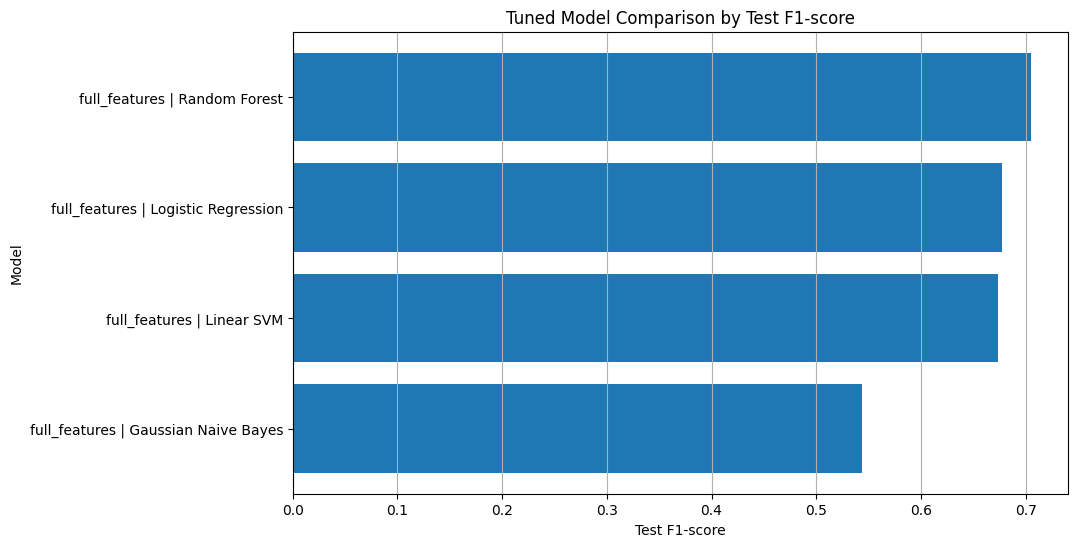

In [29]:
# Visualize tuned model comparison

plt.figure(figsize=(10, 6))

labels = tuning_results_df["feature_set"] + " | " + tuning_results_df["model"]

plt.barh(labels, tuning_results_df["test_f1_score"])
plt.xlabel("Test F1-score")
plt.ylabel("Model")
plt.title("Tuned Model Comparison by Test F1-score")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

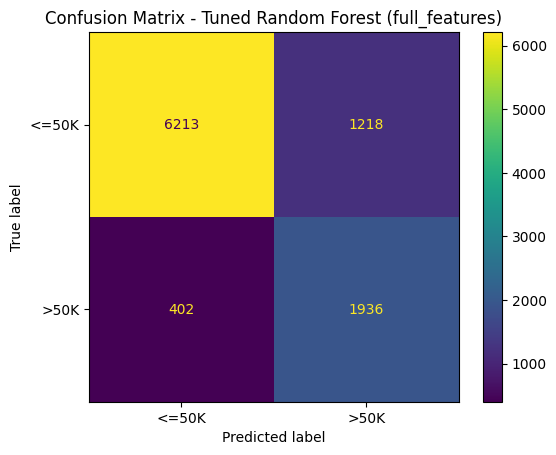

In [30]:
# Confusion matrix for best tuned model

best_tuned_model_name = best_tuned["model"]
best_tuned_y_pred = tuned_predictions[best_tuned_model_name]

cm = confusion_matrix(y_test_model, best_tuned_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix - Tuned {best_tuned_model_name} ({main_feature_set})")
plt.show()

In [31]:
# Detailed classification report for best tuned model

print(f"Classification report for tuned model: {best_tuned_model_name}")
print()

print(classification_report(
    y_test_model,
    best_tuned_y_pred,
    target_names=["<=50K", ">50K"],
    zero_division=0
))

Classification report for tuned model: Random Forest

              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.88      7431
        >50K       0.61      0.83      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.83      0.79      9769
weighted avg       0.86      0.83      0.84      9769



## [Pipeline 3.4] ROC Curve Visualization

Bên cạnh ROC-AUC score, nhóm trực quan hóa đường cong ROC của các mô hình sau tuning trên cùng một biểu đồ. Biểu đồ ROC giúp quan sát trực quan khả năng phân biệt hai lớp của từng mô hình ở nhiều ngưỡng quyết định khác nhau.


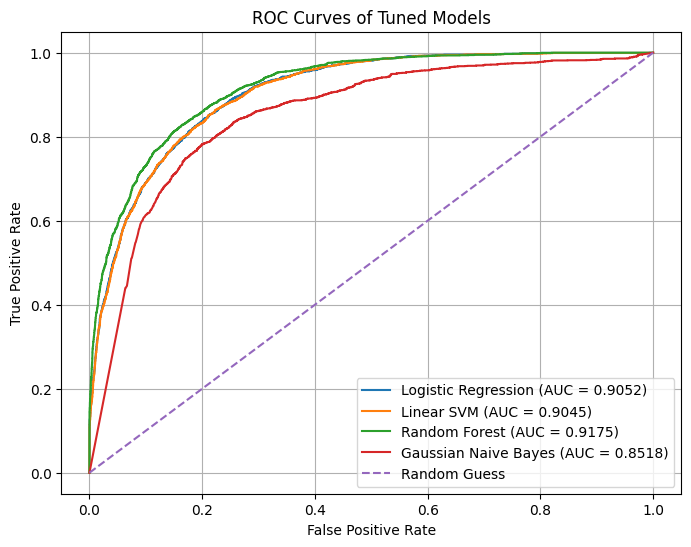

In [32]:
# Plot ROC curves for all tuned models

plt.figure(figsize=(8, 6))

for model_name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tune)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_tune)
    else:
        print(f"Skip {model_name}: no probability score or decision function available.")
        continue

    fpr, tpr, _ = roc_curve(y_test_model, y_score)
    auc_score = roc_auc_score(y_test_model, y_score)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Tuned Models")
plt.legend()
plt.grid(True)
plt.show()


## [Pipeline 3.5] Final Comparison and Model Selection

Sau khi hoàn thành baseline training và hyperparameter tuning, nhóm tiến hành so sánh mô hình baseline tốt nhất với mô hình sau tuning tốt nhất.

Mục tiêu của bước này là chọn ra mô hình cuối cùng cho classical machine learning pipeline dựa trên các chỉ số đánh giá chính, đặc biệt là F1-score và ROC-AUC.

In [33]:
# Compare best baseline model and best tuned model

final_comparison = pd.DataFrame([
    {
        "stage": "Best Baseline",
        "feature_set": best_baseline["feature_set"],
        "model": best_baseline["model"],
        "accuracy": best_baseline["accuracy"],
        "precision": best_baseline["precision"],
        "recall": best_baseline["recall"],
        "f1_score": best_baseline["f1_score"],
        "roc_auc": best_baseline["roc_auc"],
        "time_sec": best_baseline["train_time_sec"],
        "params": "default baseline params"
    },
    {
        "stage": "Best Tuned",
        "feature_set": best_tuned["feature_set"],
        "model": best_tuned["model"],
        "accuracy": best_tuned["test_accuracy"],
        "precision": best_tuned["test_precision"],
        "recall": best_tuned["test_recall"],
        "f1_score": best_tuned["test_f1_score"],
        "roc_auc": best_tuned["test_roc_auc"],
        "time_sec": best_tuned["tuning_time_sec"],
        "params": best_tuned["best_params"]
    }
])

final_comparison

,stage,feature_set,model,accuracy,precision,recall,f1_score,roc_auc,time_sec,params
0,Best Baseline,full_features,Logistic Regression,0.807350,0.565706,0.839607,0.675964,0.905146,2.023212,default baseline params
1,Best Tuned,full_features,Random Forest,0.834169,0.613824,0.828058,0.705025,0.917528,368.300987,"{'n_estimators': 150, 'min_samples_split': 2, ..."


In [34]:
# Calculate improvement from baseline to tuned model

baseline_f1 = best_baseline["f1_score"]
tuned_f1 = best_tuned["test_f1_score"]

baseline_acc = best_baseline["accuracy"]
tuned_acc = best_tuned["test_accuracy"]

baseline_auc = best_baseline["roc_auc"]
tuned_auc = best_tuned["test_roc_auc"]

f1_improvement = tuned_f1 - baseline_f1
acc_improvement = tuned_acc - baseline_acc
auc_improvement = tuned_auc - baseline_auc

relative_f1_improvement = f1_improvement / baseline_f1 * 100

print("Improvement after tuning:")
print(f"F1-score improvement : {f1_improvement:.4f}")
print(f"Accuracy improvement : {acc_improvement:.4f}")
print(f"ROC-AUC improvement  : {auc_improvement:.4f}")
print(f"Relative F1 improvement: {relative_f1_improvement:.2f}%")

Improvement after tuning:
F1-score improvement : 0.0291
Accuracy improvement : 0.0268
ROC-AUC improvement  : 0.0124
Relative F1 improvement: 4.30%


In [35]:
# Save final comparison table

os.makedirs("results", exist_ok=True)

final_comparison.to_csv("results/final_model_comparison.csv", index=False)

print("Saved final comparison to results/final_model_comparison.csv")
print(os.listdir("results"))

Saved final comparison to results/final_model_comparison.csv
['baseline_results.csv', 'final_model_comparison.csv', 'tuning_results.csv']


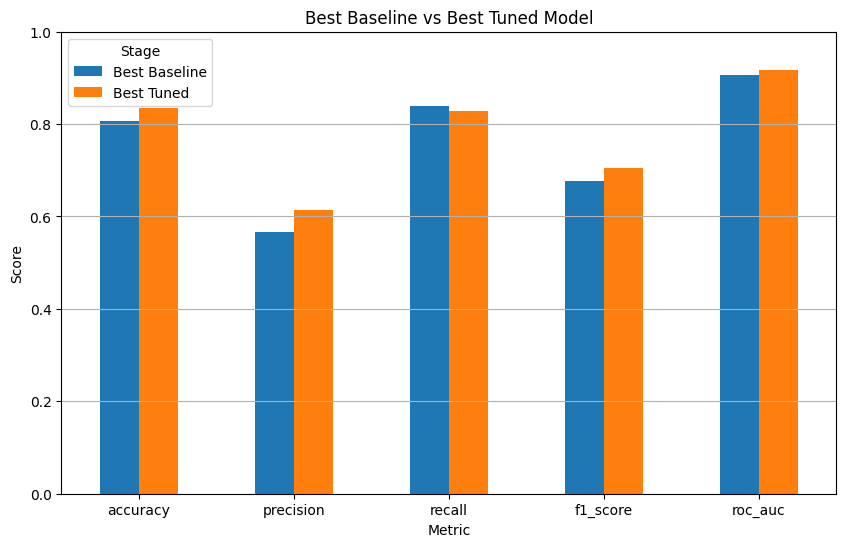

In [36]:
# Visualize final comparison

metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

plot_df = final_comparison.set_index("stage")[metrics_to_plot].T

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Best Baseline vs Best Tuned Model")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.legend(title="Stage")
plt.show()

### Nhận xét kết quả Hyperparameter Tuning

Trong bước tinh chỉnh tham số, nhóm sử dụng `full_features` làm nhánh đặc trưng chính vì đây là nhánh đạt kết quả tốt nhất ở giai đoạn baseline. Việc tuning được thực hiện bằng cross-validation trên tập train, trong khi tập test chỉ được sử dụng cho bước đánh giá cuối cùng để tránh data leakage.

So với thí nghiệm ban đầu, cross-validation được nâng từ 3 folds lên 5 folds để đánh giá ổn định hơn. Đối với Random Forest, `RandomizedSearchCV` được sử dụng với `n_iter=15` nhằm mở rộng phạm vi tìm kiếm tham số nhưng vẫn giữ thời gian chạy phù hợp với môi trường Colab.

Sau khi chạy tuning, kết quả được tổng hợp trong bảng `tuning_results_df` và so sánh với baseline trong bảng `final_comparison`. Mô hình cuối cùng được chọn dựa trên F1-score trên tập test, đồng thời tham khảo thêm accuracy và ROC-AUC.

Nếu mô hình sau tuning cải thiện F1-score so với baseline, điều này cho thấy việc lựa chọn siêu tham số có ảnh hưởng tích cực đến hiệu quả phân loại. Ngược lại, nếu mức cải thiện nhỏ, điều đó cho thấy cấu hình baseline ban đầu đã tương đối phù hợp với dữ liệu.

### Final Model Selection

Dựa trên kết quả thực nghiệm, nhóm chọn mô hình có F1-score cao nhất trên tập test sau bước hyperparameter tuning làm mô hình cuối cùng cho classical machine learning pipeline.

Trong thí nghiệm này, Random Forest sau tuning là mô hình được ưu tiên xem xét vì mô hình này có khả năng mô hình hóa các quan hệ phi tuyến và tương tác giữa các đặc trưng, phù hợp với dữ liệu dạng bảng như Adult dataset. Ngoài ra, Random Forest cũng hỗ trợ phân tích `feature_importances_`, giúp nhóm đánh giá đặc trưng nào đóng góp nhiều hơn vào quyết định phân loại.

Lý do lựa chọn mô hình cuối cùng:

1. **F1-score là chỉ số chính**  
   F1-score cân bằng giữa precision và recall, phù hợp với tập Adult do dữ liệu có sự mất cân bằng giữa hai lớp thu nhập.

2. **ROC-AUC phản ánh khả năng phân biệt lớp**  
   ROC-AUC được sử dụng bổ sung để đánh giá khả năng tách biệt hai lớp trên nhiều ngưỡng quyết định khác nhau.

3. **Phù hợp với dữ liệu tabular**  
   Random Forest có thể học các quan hệ phi tuyến và tương tác giữa đặc trưng, trong khi vẫn hoạt động tốt trên dữ liệu dạng bảng.

4. **Không cần PCA để đạt kết quả tốt nhất**  
   Kết quả baseline cho thấy `full_features` hoạt động tốt hơn hoặc tương đương `pca_95` với các mô hình chính. Vì vậy, nhánh `full_features` được sử dụng cho tuning và lựa chọn mô hình cuối cùng.

Sau khi chạy lại toàn bộ notebook, các giá trị cụ thể của mô hình cuối cùng được thể hiện trong bảng `final_comparison` và các biểu đồ đánh giá phía trên.

## [Pipeline 3.6] Feature Importance Analysis

Vì Random Forest là mô hình được ưu tiên lựa chọn sau tuning, nhóm phân tích thêm độ quan trọng của các đặc trưng. Phân tích này giúp kết nối kết quả mô hình với EDA và trả lời câu hỏi: những đặc trưng nào có ảnh hưởng lớn hơn đến dự đoán thu nhập.


,feature,importance
0,educational-num,0.124412
1,marital-status_Married-civ-spouse,0.123851
2,age,0.121575
3,relationship_Husband,0.091991
4,capital-gain,0.091989
5,hours-per-week,0.062213
6,marital-status_Never-married,0.058706
7,relationship_Own-child,0.027958
8,capital-loss,0.026179
9,relationship_Not-in-family,0.025414


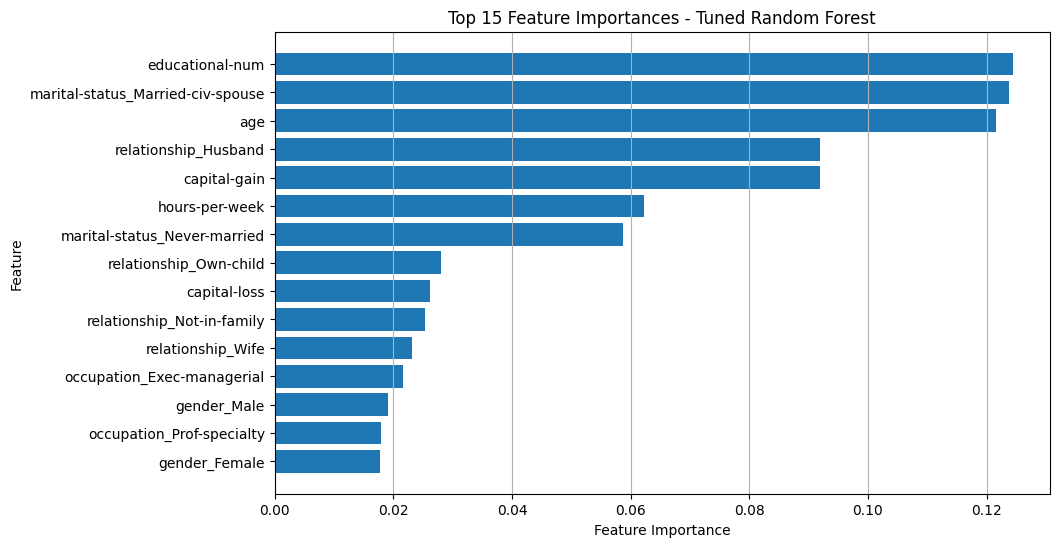

In [37]:
# Feature importance analysis for the selected Random Forest model

# Build feature names in the same order as ColumnTransformer output
cat_encoder = best_preprocessor.named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

feature_names = np.concatenate([
    np.array(num_features),
    cat_feature_names
])

# Random Forest is expected to be the final selected model in this experiment.
# If another model is selected after re-running tuning, use the tuned Random Forest model
# specifically for feature importance analysis.
rf_model_for_importance = tuned_models.get("Random Forest", None)

if rf_model_for_importance is None or not hasattr(rf_model_for_importance, "feature_importances_"):
    print("Random Forest model with feature_importances_ is not available.")
else:
    importances = rf_model_for_importance.feature_importances_

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df.head(15).sort_values(by="importance", ascending=True)

    plt.barh(top_features["feature"], top_features["importance"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Top 15 Feature Importances - Tuned Random Forest")
    plt.grid(axis="x")
    plt.show()


### Nhận xét Feature Importance

Biểu đồ feature importance cho thấy các đặc trưng có đóng góp lớn nhất vào quyết định phân loại của Random Forest. Với bài toán thu nhập trên Adult dataset, các đặc trưng liên quan đến trình độ học vấn, tình trạng hôn nhân, độ tuổi, số giờ làm việc mỗi tuần và các nhóm nghề nghiệp thường có ảnh hưởng đáng kể đến dự đoán.

Kết quả này phù hợp với phân tích EDA trước đó: thu nhập cá nhân thường có mối liên hệ với trình độ học vấn, loại công việc, độ tuổi và thời lượng làm việc. Tuy nhiên, feature importance của Random Forest chỉ phản ánh mức độ đóng góp của đặc trưng trong mô hình, không nên diễn giải như quan hệ nhân quả tuyệt đối.


In [38]:
# Save final selected model

import joblib

os.makedirs("models", exist_ok=True)

final_model = tuned_models[best_tuned_model_name]

final_model_filename = f"final_{best_tuned_model_name.replace(' ', '_').lower()}_model.pkl"
final_model_path = os.path.join("models", final_model_filename)

joblib.dump(final_model, final_model_path)

print(f"Final model saved to {final_model_path}")
print(os.listdir("models"))

Final model saved to models/final_random_forest_model.pkl
['final_random_forest_model.pkl']


In [39]:
# Verify saved model can be loaded and used for prediction

loaded_final_model = joblib.load(final_model_path)

loaded_pred = loaded_final_model.predict(X_test_tune)

print("Loaded model F1-score:", round(f1_score(y_test_model, loaded_pred), 4))
print("Loaded model Accuracy:", round(accuracy_score(y_test_model, loaded_pred), 4))

Loaded model F1-score: 0.705
Loaded model Accuracy: 0.8342


## Conclusion

Trong notebook này, nhóm đã xây dựng đầy đủ classical machine learning pipeline cho bài toán phân loại thu nhập trên Adult dataset.

Pipeline bao gồm các bước chính:

1. Load dữ liệu và tái lập preprocessing pipeline.
2. Trích xuất đặc trưng với hai nhánh: `full_features` và `pca_95`.
3. Huấn luyện baseline với Logistic Regression, Linear SVM, Random Forest và Gaussian Naive Bayes.
4. Đánh giá mô hình bằng Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix và ROC Curve.
5. Tinh chỉnh siêu tham số bằng cross-validation.
6. So sánh kết quả baseline và tuned models.
7. Phân tích feature importance cho Random Forest để hiểu thêm vai trò của các đặc trưng.
8. Lựa chọn và lưu mô hình cuối cùng.

Kết quả thực nghiệm cho thấy việc tuning giúp đánh giá mô hình có hệ thống hơn so với chỉ dùng cấu hình baseline. Nhánh `full_features` được chọn làm hướng chính vì PCA không cải thiện rõ rệt hiệu năng của các mô hình chính trong giai đoạn baseline. Mô hình cuối cùng được chọn dựa trên F1-score trên tập test, đồng thời tham khảo accuracy và ROC-AUC để đảm bảo khả năng phân loại tổng quát.